In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from collections import Counter

In [ ]:
class ImproveAccidentCNN(nn.Module):
    def __init__(self,dropout_rate=0.2,num_classes=2):
        super().__init__()

        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.4),
        )

        self.fc = nn.Sequential(
            nn.Linear(256*14*14,512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256,2)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)
        return x

In [17]:
# -------- Training Parameters ----------
LEARNING_RATE = 1e-2
BATCH_SIZE = 32
EPOCHS = 100
WEIGHT_DECAY = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PATIENCE = 5
MIN_DELTA = 0.001
patient_cnt = 0
best_val_loss = np.inf
best_acc = 0.0              # Initialize best accuracy to 0

TRAIN = r"D:\project\dataset_cnn\train"
TEST = r"D:\project\dataset_cnn\test"

SAVE_DIR = r"D:\project\bachelor\model\weights"
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, "best_accident_cnn_model.pth")

PLOT_DIR = r"D:\project\bachelor\model\plot-result"
os.makedirs(PLOT_DIR, exist_ok=True)

# --------------------------------------


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset = datasets.ImageFolder(TRAIN,transform=train_transform)
test_dataset = datasets.ImageFolder(TEST,transform=test_transform)

print(f"Класи: {train_dataset.classes}")

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True,num_workers=2,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=True,num_workers=2,pin_memory=True)


model = ImproveAccidentCNN(num_classes=len(train_dataset.classes))
print(torch.cuda.is_available())

model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_loss = []
test_loss = []
train_accs = []
test_accs = []

for epoch in range(EPOCHS):

    model.train()
    correct = 0
    total = 0
    running_loss = 0

    for images,labels in train_loader:

        images,labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()


        running_loss += loss.item()
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


    train_loss.append(running_loss / len(train_loader))
    train_accs.append(correct / total)


    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images,labels in test_loader:
            images,labels = images.to(DEVICE),labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs,labels)

            val_loss += loss.item()
            _,predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()


    test_loss.append(val_loss / len(test_loader))
    test_accs.append(correct / total)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | "
        f"Val Loss: {test_loss[-1]:.4f} | Val Acc: {test_accs[-1]:.4f}")
    
    # Save the best model
    if test_accs[-1] > best_acc:
        best_acc = test_accs[-1]
        torch.save(model.state_dict(), r"D:\project\bachelor\model\weights\best_accident_cnn_model.pth")
        print(f"Найкраща модель збережена з точністю: {best_acc:.4f}")


    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        patient_cnt = 0
        print(f"Покращення val loss: {best_val_loss:.4f}")
    else:
        patient_cnt += 1
        print(f"Немає покращення val loss. Лічильник терпіння: {patient_cnt}/{PATIENCE}")
        if patient_cnt >= PATIENCE:
            print(f"\n Early stopping спрацював на епосі {epoch+1}")
            print(f"Найкраща val loss: {best_val_loss:.4f}")
            print(f"Найкраща val accuracy: {best_acc:.4f}")
            break    

Класи: ['1', '2']
True
Epoch 1/100 | Train Loss: 0.7220 | Train Acc: 0.5870 | Val Loss: 0.5829 | Val Acc: 0.7011
Найкраща модель збережена з точністю: 0.7011
Покращення val loss: 142.8021
Epoch 2/100 | Train Loss: 0.6277 | Train Acc: 0.6575 | Val Loss: 0.5132 | Val Acc: 0.7547
Найкраща модель збережена з точністю: 0.7547
Покращення val loss: 125.7381
Epoch 3/100 | Train Loss: 0.6011 | Train Acc: 0.6756 | Val Loss: 0.4865 | Val Acc: 0.7642
Найкраща модель збережена з точністю: 0.7642
Покращення val loss: 119.1827
Epoch 4/100 | Train Loss: 0.5641 | Train Acc: 0.7111 | Val Loss: 0.4620 | Val Acc: 0.7772
Найкраща модель збережена з точністю: 0.7772
Покращення val loss: 113.1845
Epoch 5/100 | Train Loss: 0.5553 | Train Acc: 0.7228 | Val Loss: 0.5018 | Val Acc: 0.7723
Немає покращення val loss. Лічильник терпіння: 1/5
Epoch 6/100 | Train Loss: 0.5537 | Train Acc: 0.7190 | Val Loss: 0.4631 | Val Acc: 0.7912
Найкраща модель збережена з точністю: 0.7912
Немає покращення val loss. Лічильник терп

In [18]:
model.load_state_dict(torch.load(r"D:\project\bachelor\model\weights\best_accident_cnn_model.pth"))

# Printed plots
model.eval()
true_labels = []
pred_labels = []

with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        preds = outputs.argmax(dim=1).cpu().numpy()
        pred_labels.extend(preds)
        true_labels.extend(labels.numpy())


print(classification_report(true_labels,pred_labels,target_names=train_dataset.classes))

cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=train_dataset.classes, 
            yticklabels=train_dataset.classes)
plt.title("Confusion Matrix")
plt.xlabel("Передбачено")
plt.ylabel("Справжнє")
plt.savefig(os.path.join(PLOT_DIR, "confusing_matrix.png"))
plt.close()


# Training Curves
plt.figure(figsize=(10,8))
plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")
plt.title("Крива втрат")
plt.xlabel("Епохи")
plt.ylabel("Втрати")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "training_loss.png"))
plt.close()

plt.figure(figsize=(10,8))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")
plt.title("Крива точності")
plt.xlabel("Епохи")
plt.ylabel("Точність")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "training_acc_curv.png"))
plt.close()

print(f"\n Навчання завершено. Найкраща точність на тестовому наборі: {best_acc:.4f}")


              precision    recall  f1-score   support

           1       0.99      0.89      0.94      2000
           2       0.89      0.99      0.94      1918

    accuracy                           0.94      3918
   macro avg       0.94      0.94      0.94      3918
weighted avg       0.94      0.94      0.94      3918


 Навчання завершено. Найкраща точність на тестовому наборі: 0.9372


Початок розширеної оцінки моделі...
----------------------------------------
Global Accuracy:    0.7303
Balanced Accuracy:  0.6305 (Більш чесна метрика)
----------------------------------------

Детальний звіт по класах:
                   precision    recall  f1-score      support
0_NoAccident        0.980630  0.810000  0.887185   500.000000
1_LowDangerous      0.190476  0.333333  0.242424    24.000000
2_MediumDangerous   0.640940  0.595016  0.617124   321.000000
3_HighDangerous     0.569733  0.783673  0.659794   245.000000
accuracy            0.730275  0.730275  0.730275     0.730275
macro avg           0.595445  0.630506  0.601632  1090.000000
weighted avg        0.770837  0.730275  0.742346  1090.000000


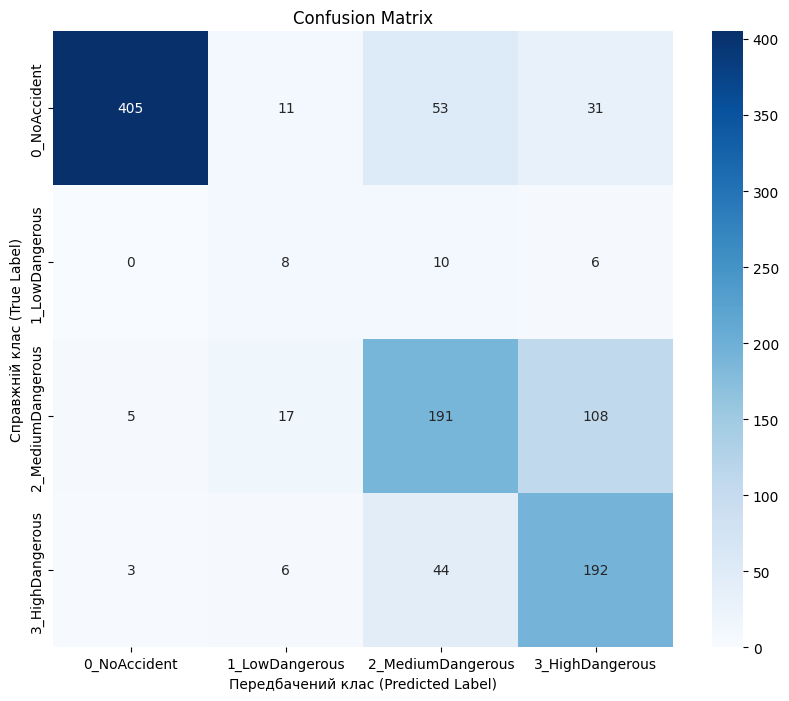


--- АНАЛІЗ БЕЗПЕКИ ---
Критичні пропуски (Була тяжка аварія, а модель сказала 'Чисто'): 3 шт.
Хибні тривоги (Було чисто, модель сказала 'Тяжка аварія'):      31 шт.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score
import pandas as pd

def evaluate_model_comprehensive(model, test_loader, device, class_names, save_path=PLOT_DIR):
    model.eval()
    y_true = []
    y_pred = []
    
    print("Початок розширеної оцінки моделі...")
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    # 1. Загальні метрики
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    print("-" * 40)
    print(f"Global Accuracy:    {acc:.4f}")
    print(f"Balanced Accuracy:  {bal_acc:.4f} (Більш чесна метрика)")
    print("-" * 40)
    
    # 2. Детальний звіт (Precision, Recall, F1)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print("\nДетальний звіт по класах:")
    print(report_df)
    
    # Збереження звіту в CSV
    report_df.to_csv(f"{save_path}/metrics_report.csv")
    
    # 3. Матриця плутанини (Графік)
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.ylabel('Справжній клас (True Label)')
    plt.xlabel('Передбачений клас (Predicted Label)')
    plt.title('Confusion Matrix')
    plt.savefig(f"{save_path}/confusion_matrix_final.png")
    plt.show()
    plt.close()
    

evaluate_model_comprehensive(model, test_loader, DEVICE, train_dataset.classes)
